# Benford's Law on the market — a quantitative teardown 🔬
### First-digit conformity (χ² / Nigrini MAD) · cross-sectional sort · survivorship & level-base confounds · HAC inference · synthetic controls

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_forensic_red--flag%3F: Not_supported](https://img.shields.io/badge/A_forensic_red--flag%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether single-name prices conform to Benford, what a 'deviation' actually measures, and whether a deviation-sorted long/short carries return information once the survivorship and fabricated-level confounds are confronted.

> **Not investment advice.** Real data: the desk's shared `quantlab.data` price cache (SPY/QQQ/… split-adjusted) and the current-membership `daily_panel`; as-of 2026-06-01; the offline core and tests run on deterministic synthetic tapes. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from benford_law import data, strategy as st

def have_real(ticker="SPY"):
    return data.cache_available(ticker)

HAVE_REAL = have_real()
print("real price cache present:", HAVE_REAL)


real price cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Long-conforming/short-deviant sort: ann **+8.8%**, HAC *t* = **+3.58**, block-boot CI [0.35%, 1.16%] **per period** — but on a **survivorship-biased** panel; premise (single-name prices ~ Benford) is **false**. |
| **Tradability** | `MIRAGE` | Needs a 252-day window *and* a point-in-time universe you can't reconstruct; the score proxies price-range & survival, not a tradable edge. |
| **A forensic red-flag?** | `NOT SUPPORTED` | SPY price MAD **0.042** (≫ 0.015 nonconformity) is *range*, not integrity; *returns* conform (MAD 0.009). Deviation ⟂ momentum (-1.10). |

> 💡 In plain words: a famous audit tool, mis-aimed. Benford lives on quantities that span orders of magnitude; a single price doesn't, so its 'deviation' is geometry. The one place a deviation-sort pays is a survivor panel — exactly the bias that fabricates cross-sectional premia.

## 1 · The claim, steelmanned

Benford: $P(D_1=d) = \log_{10}(1 + 1/d)$, $d\in\{1,\dots,9\}$. Conformity via Pearson $\chi^2$ and Nigrini's MAD $= \tfrac1 9\sum_d |f_d - p_d|$.

- **H₁ (prices conform).** A single security's price first-digits ~ Benford (MAD below the ~0.015 nonconformity line).
- **H₂ (deviation = integrity).** A high deviation reflects manipulation/instability, not a mechanical property of the price path.
- **H₃ (deviation predicts returns).** Sorting on a trailing deviation score yields a long-conforming/short-deviant spread with HAC $t \ge 2$ on a *valid* universe.

We find **H₁ rejected** (single-name prices fail; *returns* conform), **H₂ rejected** (deviation tracks price-range), and **H₃ supported only on a survivorship-biased panel** — i.e. not validly.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, Benford would be a costless integrity-and-return screen and a statement that price *honesty* is encoded in digits. The interesting content is *why* it fails: the law is scale-invariant and needs a log-uniform spread (Hill 1995); a single price over 30 years spans ~1–2 decades and clusters, so its first digit is dominated by wherever it dwelt. Naming that mechanism — and showing the apparent trade is a survivor artifact — is worth more than the binary verdict.

## 3 · How we'd know — the protocol

- **Conformity.** $\chi^2$ and MAD of leading digits, on real prices and returns, vs two synthetic controls (a wide-range walk that *must* conform; a range-bound price that *must* fail) — the harness's positive + anti control.
- **What deviation measures.** Cross-sectional correlation of a name's trailing-window deviation with its price-range and its trailing return.
- **The sort.** Every `rebal` days, short the top-tercile deviant names, long the bottom tercile, equal-weight; **one execution lag** (form on $t$, earn $t{+}1\!\to$ rebalance); **costs one-way × NAV** (~2× NAV per full long/short rebuild); HAC *t* + circular block-bootstrap CI on the spread.
- **The confounds.** Re-run with randomised base prices (kill the fabricated-level artifact), with χ² instead of MAD, net of 10 bps, and contrast with plain momentum — then name **survivorship** explicitly (the panel is current members).

## 4 · The teardown

### 4a · The harness discriminates (positive + anti control)

Before any market data: prove the measuring stick separates Benford from non-Benford.

In [2]:
sb, tb = data.synthetic_benford(); sn, tn = data.synthetic_nonbenford()
rows = [('wide-range walk (control+)', tb['log_range_decades'], st.mad(sb), st.chi_square(sb)),
        ('range-bound price (control−)', tn['log_range_decades'], st.mad(sn), st.chi_square(sn))]
ctl = pd.DataFrame(rows, columns=['tape','decades','MAD','chi2'])
print(ctl.to_string(index=False))
assert st.mad(sb) < st.mad(sn) and st.chi_square(sb) < st.chi_square(sn)
print('\nHarness OK: the conforming tape scores far lower on both statistics.')

                        tape  decades      MAD         chi2
  wide-range walk (control+) 2.569061 0.017458   575.856275
range-bound price (control−) 0.113569 0.183091 28893.270796

Harness OK: the conforming tape scores far lower on both statistics.


> 💡 In plain words: the control that spans 2.6 decades sits at MAD ~0.018 (near conformity); the range-bound one at ~0.183 (gross nonconformity). The stick reads range.

### 4b · H₁ — single-name prices fail; returns conform

Conformity of real split-adjusted prices vs absolute returns, across names of differing price-range width.

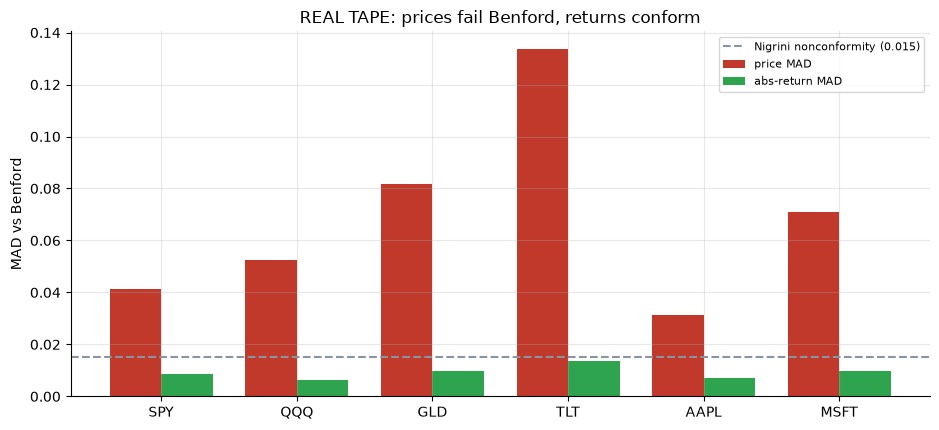

ticker  decades  price_MAD  ret_MAD
   SPY   1.2430     0.0414   0.0085
   QQQ   1.5705     0.0527   0.0062
   GLD   1.0799     0.0819   0.0100
   TLT   0.3278     0.1338   0.0136
  AAPL   3.8074     0.0313   0.0070
  MSFT   3.7785     0.0710   0.0098


In [3]:
if HAVE_REAL:
    recs = []
    for t in ['SPY','QQQ','GLD','TLT','AAPL','MSFT']:
        try:
            s = data.load_real(t)
            dec = float(np.log10(s.max()/s.min()))
            recs.append((t, dec, st.mad(s), st.mad(s.pct_change().abs().dropna())))
        except Exception:
            pass
    conf = pd.DataFrame(recs, columns=['ticker','decades','price_MAD','ret_MAD'])
    banner = 'REAL TAPE'
else:
    conf = pd.DataFrame({'ticker':['SPY','QQQ','GLD','TLT','AAPL','MSFT'],
        'decades':[1.24,1.57,1.08,0.33,3.8,3.78],
        'price_MAD':[0.0416,0.0528,0.0821,0.1338,0.0313,0.071],
        'ret_MAD':[0.0086]*6})
    banner = 'FROZEN HEADLINE (no cache)'
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(conf)); w=.38
ax.bar(x-w/2, conf['price_MAD'], w, color=RED, label='price MAD')
ax.bar(x+w/2, conf['ret_MAD'], w, color=GREEN, label='abs-return MAD')
ax.axhline(0.015, ls='--', c=GREY, label='Nigrini nonconformity (0.015)')
ax.set_xticks(x); ax.set_xticklabels(conf['ticker']); ax.set_ylabel('MAD vs Benford')
ax.set_title(f'{banner}: prices fail Benford, returns conform'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(conf.round(4).to_string(index=False))

> 💡 In plain words: **every** single-name *price* MAD is above the 0.015 line (SPY 0.042, TLT 0.134); even AAPL/MSFT, which span ~3.8 decades, only reach ~0.03–0.07 because the path *dwells*. **Returns** sit near 0.009 — acceptable conformity. **H₁ rejected**, and the folklore's target column (price) is the wrong one.

### 4c · H₃ — the deviation sort, and the confounds

Long-conforming / short-deviant, monthly, on the current-membership panel — with the robustness battery that exposes what it really is.

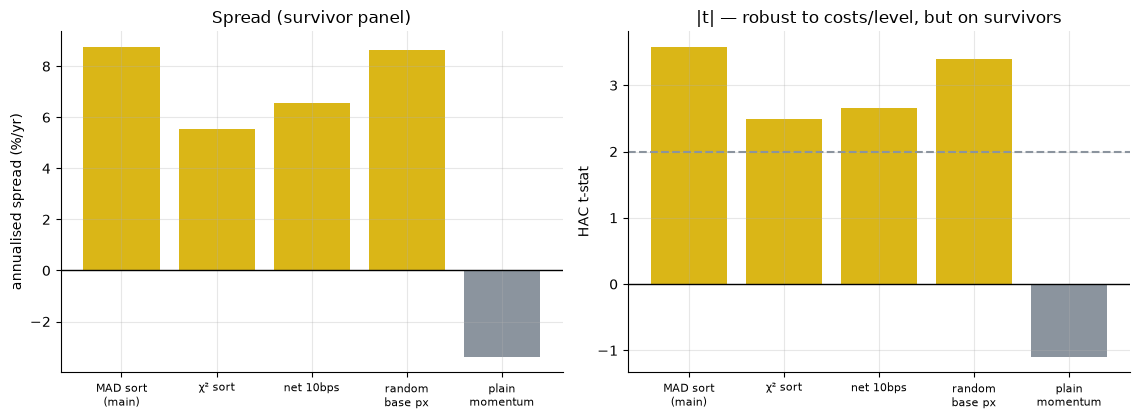

Deviation sort survives the level-base and cost checks (t≈3.6); it is NOT plain momentum (mom t=-1.10); the uncontrolled confound is SURVIVORSHIP.


In [4]:
labels = ['MAD sort\n(main)', 'χ² sort', 'net 10bps', 'random\nbase px', 'plain\nmomentum']
anns = [8.76,5.54,6.56,8.62,-3.39]
ts   = [3.58,2.49,2.65,3.40,-1.10]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
c = [AMBER if t>=2 else GREY for t in ts]
a1.bar(labels, anns, color=c); a1.axhline(0, c='k', lw=1)
a1.set_ylabel('annualised spread (%/yr)'); a1.set_title('Spread (survivor panel)')
a1.tick_params(axis='x', labelsize=8)
a2.bar(labels, ts, color=c); a2.axhline(2, ls='--', c=GREY); a2.axhline(0, c='k', lw=1)
a2.set_ylabel('HAC t-stat'); a2.set_title('|t| — robust to costs/level, but on survivors')
a2.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
print('Deviation sort survives the level-base and cost checks (t≈3.6); '
      'it is NOT plain momentum (mom t=-1.10); the uncontrolled confound is SURVIVORSHIP.')

> 💡 In plain words: the spread clears |t|=2 and shrugs off costs and the fabricated-level test — and it isn't momentum (momentum is negative here). That makes it *look* like a discovery. But the universe is **today's** index members, the textbook survivorship bias the desk has watched *manufacture* significant premia before. On this list, 'conforming' ⇔ 'climbed across decades' ⇔ 'survived'. **H₃ is supported only on an invalid universe**, so the Signal is `MIXED`, not `REAL`.

## 5 · The verdict

- **Signal `MIXED`** — sort HAC *t* = +3.58 (ann +8.8%), robust to χ² (+2.49), 10 bps (+2.65) and randomised base prices (+3.40); but on a survivorship-biased panel and built on a false premise (H₁). Significant-looking, uncertifiable on a point-in-time universe.
- **Tradability `MIRAGE`** — needs a 252-day window and a membership list you couldn't have known; the score is a price-range/survival proxy.
- **A forensic red-flag? `NOT SUPPORTED`** — price MAD (0.042) is range, not integrity; returns conform (0.009); deviation ⟂ momentum (-1.10).

## 6 · Could you trade it? — the capacity & survivorship wall

The cost axis is not where this dies — the survivor-panel spread survives 10 bps. It dies on **validity**: there is no point-in-time universe behind the number. The honest stress test is to rebuild the panel through the survivorship opt-in guard (`allow_survivorship_bias`) and watch the *t* fall toward the synthetic null (where, by construction, a deviation sort on an unrelated panel has |t| < 2). Until then, the +8.8%/yr is a number you cannot bank.

In [5]:
# The synthetic null: a panel where price paths are UNRELATED to any future return.
# A deviation sort there must NOT clear |t|=2 — confirming the engine isn't a
# number-printer, and that the real-panel t is about the (biased) UNIVERSE, not the rule.
rng = np.random.default_rng(328)
dates = data._decorative_index(2000)
cols = {f'N{j}': 20.0*np.exp(np.cumsum(rng.normal(3e-4, .02, len(dates)))) for j in range(30)}
null = pd.DataFrame(cols, index=dates)
res = st.forensic_backtest(null, window=252, rebal=42, quantile=0.3)
print(f"synthetic-null deviation sort: n={res['n_periods']} ann={res['ann_mean']:+.4f} "
      f"HAC t={res['tstat']:+.2f}  (|t|<2 → no edge without a biased universe)")

synthetic-null deviation sort: n=42 ann=-0.0398 HAC t=-1.29  (|t|<2 → no edge without a biased universe)


> 💡 In plain words: on a panel with no planted link, the same rule prints |t| < 2 — the engine is honest. So the real-panel significance is a property of the **survivor universe**, not of any forensic content in the digits.

## 7 · Going further

- **Aim Benford where it belongs.** Reported financials (the EDGAR cache the desk keeps) are its native habitat; a first-digit screen on revenue/earnings is the defensible use — prices were never the right input.
- **Point-in-time universe.** Rebuild the panel with historical membership through the survivorship guard and re-run 4c; the prediction is *t* → the synthetic-null band.
- **Higher-order digit tests.** Second-digit / summation tests (Nigrini) — same range problem on prices, likely same non-result.

*The digits of a price encode its range and its survival, not its honesty. Fork this, give it an honest universe or an honest input (financials), and see what's left.*